<a href="https://colab.research.google.com/github/carolmarquezini/preta_lab/blob/main/Projeto04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projeto 4: Estatística com Python - Probabilidade, Amostragem e Testes de Hipóteses

## Objetivo do Projeto:

O objetivo deste projeto é aplicar os conceitos aprendidos sobre Estatística Descritiva, Probabilidade, Amostragem e Testes de Hipóteses.

O projeto irá avaliar a compreensão dos tópicos abordados e como conseguem aplicar as ferramentas estatísticas para realizar uma análise real usando dados.

## Cenário:

A base de dados para esse projeto será a "Telco Customer Churn",disponível no Kaggle,  que contém dados sobre a rotatividade de clientes de uma empresa de telecomunicações.

A análise desse dataset é interessante, pois permite explorar a jornada do cliente, entender o comportamento daqueles que deixam a empresa e realizar testes de hipóteses para identificar os fatores que influenciam essa decisão.

link do dataset -[ Telco Customer Churn](
  https://www.kaggle.com/datasets/alfathterry/telco-customer-churn-11-1-3)

**Forma de baixar a base**

In [1]:
# Montando o Google Drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/pretaLab-ciclo11/projeto04/

/content/drive/MyDrive/pretaLab-ciclo11/projeto04


In [15]:
!ls

Projeto04.ipynb  telco.csv


In [32]:
import kagglehub
import os
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind, chi2_contingency, f_oneway
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [12]:
# Download latest version
# path = kagglehub.dataset_download("alfathterry/telco-customer-churn-11-1-3")
path = '/root/.cache/kagglehub/datasets/alfathterry/telco-customer-churn-11-1-3/versions/1'

print("Path to dataset files:", path)

Path to dataset files: /root/.cache/kagglehub/datasets/alfathterry/telco-customer-churn-11-1-3/versions/1


In [16]:
# Carregar os dados

# df = pd.read_csv('/root/.cache/kagglehub/datasets/alfathterry/telco-customer-churn-11-1-3/versions/1/Telco-Customer-Churn.csv')

df = pd.read_csv('/content/drive/MyDrive/pretaLab-ciclo11/projeto04/telco.csv')


In [17]:
df.head()

,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,...,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,...,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,...,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,...,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,...,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,...,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges


## Instruções do Projeto:

### Conceitos Básicos de Estatística em Python - Estatística Descritiva

Nesta primeira etapa, você irá realizar uma análise descritiva dos dados. Escolha algumas colunas que representam variáveis importantes para o negócio *(por exemplo, churn, tenure, monthly charges)* e responda às seguintes perguntas:

***Distribuição dos dados:***
1. Qual é a média, mediana, moda e desvio padrão do tempo de permanência (tenure) dos clientes?

In [23]:
tenure_mean = df['Tenure in Months'].mean()
tenure_median = df['Tenure in Months'].median()
tenure_mode = df['Tenure in Months'].mode()[0]
tenure_std = df['Tenure in Months'].std()

print(f"Tempo de Permanência (Tenure in Months):")
print(f"Média: {tenure_mean:.2f}")
print(f"Mediana: {tenure_median}")
print(f"Moda: {tenure_mode}")
print(f"Desvio Padrão: {tenure_std:.2f}\n")


Tempo de Permanência (Tenure in Months):
Média: 32.39
Mediana: 29.0
Moda: 1
Desvio Padrão: 24.54



***Análise de dispersão:***

2. Quais são os quartis e percentis do valor das cobranças mensais (monthly charges) e das taxas de rescisão (churn)?


In [24]:
monthly_quartiles = df['Monthly Charge'].quantile([0.25, 0.5, 0.75])
monthly_percentiles = df['Monthly Charge'].quantile([0.1, 0.9])

print(f"Quartis das Cobranças Mensais (Monthly Charge):")
print(monthly_quartiles)
print(f"Percentis 10% e 90% das Cobranças Mensais:\n{monthly_percentiles}\n")


Quartis das Cobranças Mensais (Monthly Charge):
0.25    35.50
0.50    70.35
0.75    89.85
Name: Monthly Charge, dtype: float64
Percentis 10% e 90% das Cobranças Mensais:
0.1     20.05
0.9    102.60
Name: Monthly Charge, dtype: float64





***Visualização:***

3. Utilize gráficos como histograma e boxplot para visualizar a distribuição dos dados.

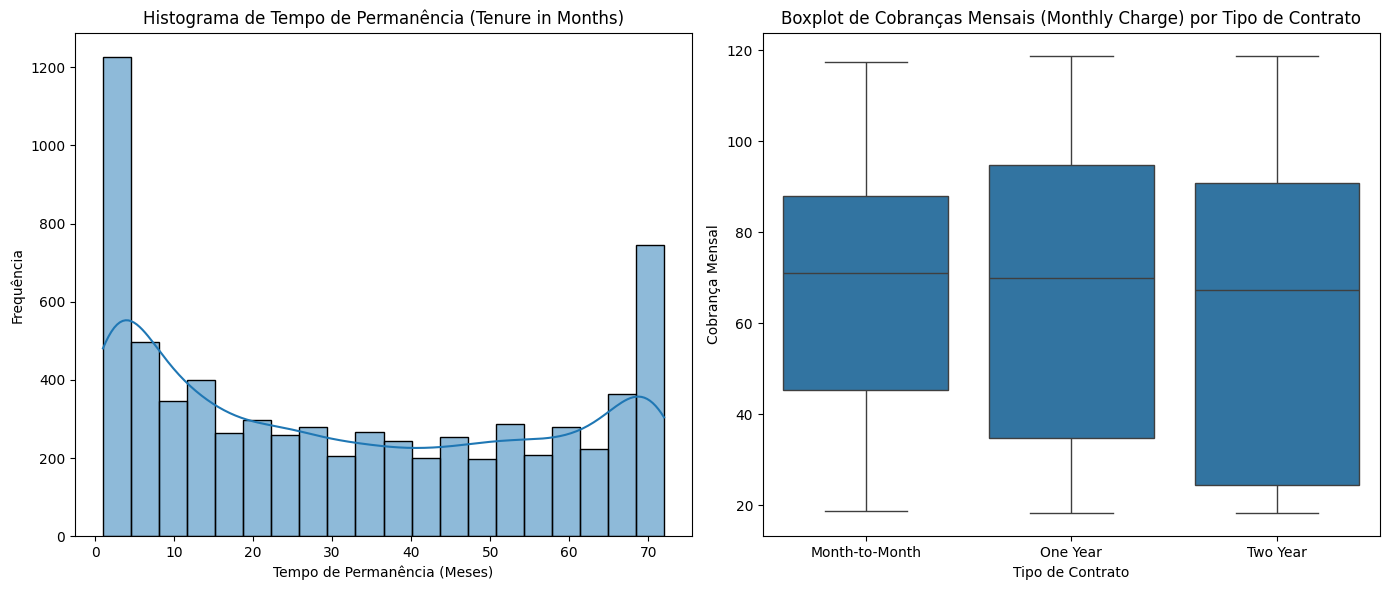

In [27]:
plt.figure(figsize=(14, 6))

# Histograma de 'Tenure in Months'
plt.subplot(1, 2, 1)
sns.histplot(df['Tenure in Months'], kde=True, bins=20)
plt.title('Histograma de Tempo de Permanência (Tenure in Months)')
plt.xlabel('Tempo de Permanência (Meses)')
plt.ylabel('Frequência')

# Boxplot de 'Monthly Charge'
plt.subplot(1, 2, 2)
sns.boxplot(x='Contract', y='Monthly Charge', data=df)
plt.title('Boxplot de Cobranças Mensais (Monthly Charge) por Tipo de Contrato')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Cobrança Mensal')

plt.tight_layout()
plt.show()

### Probabilidade, Amostragem e Testes de Hipóteses

Agora que você já realizou uma análise descritiva, vamos nos aprofundar em probabilidade, amostragem e testes de hipóteses.

***Amostragem:***

1. Escolha uma amostra aleatória de 30% dos dados.

Tipos de Amostragem: Utilize amostragem aleatória simples e estratificada para escolher as amostras, explicando as diferenças entre elas.


In [28]:
# Definindo uma semente para reprodutibilidade
np.random.seed(42)

# Amostragem Aleatória Simples
simple_sample = df.sample(frac=0.3, random_state=42)

# Amostragem Estratificada
# A primeira coluna deve ser uma variável categórica; vamos usar a coluna 'Contract' para estratificar.
stratified_sample = df.groupby('Contract').apply(lambda x: x.sample(frac=0.3, random_state=42)).reset_index(drop=True)

print(f"Amostra Aleatória Simples (30% dos dados):\n{simple_sample.head()}\n")
print(f"Amostra Estratificada (30% dos dados por tipo de contrato):\n{stratified_sample.head()}\n")

Amostra Aleatória Simples (30% dos dados):
     Customer ID  Gender  Age Under 30 Senior Citizen Married Dependents  \
185   1732-VHUBQ  Female   73       No            Yes     Yes         No   
2715  6292-TOSSS    Male   64       No             No      No         No   
3825  2546-KZAAT    Male   28      Yes             No     Yes         No   
1807  4946-EDSEW  Female   35       No             No     Yes        Yes   
132   9061-TIHDA    Male   67       No            Yes     Yes         No   

      Number of Dependents        Country       State  ...  \
185                      0  United States  California  ...   
2715                     0  United States  California  ...   
3825                     0  United States  California  ...   
1807                     3  United States  California  ...   
132                      0  United States  California  ...   

     Total Extra Data Charges  Total Long Distance Charges  Total Revenue  \
185                         0                     

<ipython-input-28-88b8272f6f7a>:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stratified_sample = df.groupby('Contract').apply(lambda x: x.sample(frac=0.3, random_state=42)).reset_index(drop=True)


***Probabilidade:***

2. Calcule a probabilidade de um cliente encerrar o serviço (churn) com base em características como tempo de permanência (tenure) e cobranças mensais (monthly charges).

In [30]:
print(df.columns)

Index(['Customer ID', 'Gender', 'Age', 'Under 30', 'Senior Citizen', 'Married',
       'Dependents', 'Number of Dependents', 'Country', 'State', 'City',
       'Zip Code', 'Latitude', 'Longitude', 'Population', 'Quarter',
       'Referred a Friend', 'Number of Referrals', 'Tenure in Months', 'Offer',
       'Phone Service', 'Avg Monthly Long Distance Charges', 'Multiple Lines',
       'Internet Service', 'Internet Type', 'Avg Monthly GB Download',
       'Online Security', 'Online Backup', 'Device Protection Plan',
       'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
       'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds',
       'Total Extra Data Charges', 'Total Long Distance Charges',
       'Total Revenue', 'Satisfaction Score', 'Customer Status', 'Churn Label',
       'Churn Score', 'CLTV', 'Churn Category', 'Churn Reason'],
      dtype='object')


In [31]:
# Considerando que existe uma coluna 'Churn' que indica se o cliente cancelou (1) ou não (0)
# Caso não exista, pode-se inferir com base na coluna 'Contract', por exemplo, clientes com contratos mensais podem ter maior churn.

# Adicionar coluna de churn como numérica
df['Churn'] = np.where(df['Churn Label'] == 'Yes', 1, 0)

# Proporção de clientes que cancelaram o serviço
prob_churn = df['Churn'].mean()
print(f"Probabilidade de um cliente encerrar o serviço (churn): {prob_churn:.2f}")

# Cálculo de probabilidade condicionada
prob_churn_tenure = df[df['Tenure in Months'] < 12]['Churn'].mean()
print(f"Probabilidade de churn para clientes com menos de 12 meses: {prob_churn_tenure:.2f}")

prob_churn_monthly_charge = df[df['Monthly Charge'] > 80]['Churn'].mean()
print(f"Probabilidade de churn para clientes com cobranças mensais superiores a 80: {prob_churn_monthly_charge:.2f}")


Probabilidade de um cliente encerrar o serviço (churn): 0.27
Probabilidade de churn para clientes com menos de 12 meses: 0.48
Probabilidade de churn para clientes com cobranças mensais superiores a 80: 0.34



***Testes de Hipóteses:***

1. Escolha duas variáveis relevantes (por exemplo, churn e tipo de contrato) e formule uma hipótese nula (H0) e uma hipótese alternativa (H1).

2. Realize um Teste T ou ANOVA para verificar se há diferença significativa nas cobranças mensais entre clientes que cancelam o serviço e aqueles que não cancelam.

3. Analise o valor-p e interprete os resultados.

In [33]:
# Hipóteses
H0 = "Não há diferença significativa nas cobranças mensais entre clientes que cancelam e aqueles que não cancelam."
H1 = "Há uma diferença significativa nas cobranças mensais entre os dois grupos."

# Separar os grupos
churn_group = df[df['Churn Label'] == 1]['Monthly Charge']
no_churn_group = df[df['Churn Label'] == 0]['Monthly Charge']

# Teste T
t_stat, p_value = stats.ttest_ind(churn_group, no_churn_group)

# Imprimir resultados
print(f"Estatística T: {t_stat}")
print(f"Valor-p: {p_value}")

# Análise do Valor-p
alpha = 0.05
if p_value < alpha:
    result = "Rejeita H0: há diferença significativa nas cobranças mensais."
else:
    result = "Não rejeita H0: não há diferença significativa nas cobranças mensais."

print(result)


Estatística T: nan
Valor-p: nan
Não rejeita H0: não há diferença significativa nas cobranças mensais.


## O que entregar:

1. Um notebook com a análise completa.

2. A análise descritiva dos dados.

3. A aplicação da amostragem e cálculo de probabilidade.

4. O resultado dos testes de hipóteses com a interpretação crítica.